# 03.4 - Hypothesis Testing

**Phase:** 03 - Statistics & Probability

**Status:** VERIFIED

---

## 1. What Are We Solving?

**Hypothesis testing** answers questions like: 'Is this drug effective?', 'Does this feature improve the model?', 'Are these two groups different?'. It provides a rigorous, quantitative way to make decisions under uncertainty, using **null hypotheses**, **p-values**, and **statistical tests**.

## 2. Why Does This Matter?

In ML, hypothesis testing is used to compare models, validate that a new feature helps, and check assumptions. Understanding p-values prevents the common mistake of over-interpreting small differences as significant.

## 3. Prerequisites

- Unit 03.3 (Inferential statistics & sampling)
- Unit 03.2 (Probability distributions)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- Define null and alternative hypotheses
- Understand p-values and significance levels
- Understand Type I and Type II errors
- Run and interpret t-tests
- Avoid common misinterpretations of p-values

## 5. Mental Model

We start with a **null hypothesis** `H0` (e.g. 'there is no difference') and an **alternative** `H1` (e.g. 'there is a difference'). We compute a **test statistic** from the data and a **p-value**: the probability of observing data this extreme *if H0 were true*. If the p-value is very small (below the **significance level**, usually 0.05), we **reject H0** as unlikely.

Key: a small p-value means 'the data is surprising under H0', not 'H0 is false with 95% probability'.


## 6. Null and Alternative Hypotheses

- **Null hypothesis (H0)**: the default assumption, usually 'no effect' or 'no difference'.
- **Alternative hypothesis (H1)**: what we're testing for, e.g. 'there is a difference'.

Example: testing whether a new drug lowers blood pressure.
- H0: the drug has no effect (mean change = 0).
- H1: the drug has an effect (mean change != 0).

We gather evidence to see if we can reject H0.


## 7. The t-test

The **t-test** compares a sample mean to a known value (one-sample) or two sample means (two-sample). The **t-statistic** measures how many standard errors the sample mean is from the hypothesized value.

One-sample t-test: `t = (sample_mean - hypothesized_mean) / SE`

Let's test whether a sample comes from a population with mean 100.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# One-sample t-test: is the mean different from 100?
sample = np.random.normal(102, 15, size=50)
hypothesized_mean = 100

t_stat, p_value = stats.ttest_1samp(sample, hypothesized_mean)

print(f"Sample mean: {np.mean(sample):.2f}")
print(f"Hypothesized mean: {hypothesized_mean}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0 (p < 0.05): {p_value < 0.05}")
print("\nThe p-value tells us whether the observed sample mean is surprising")
print("if the true mean were 100. If p < 0.05, we reject H0.")


Sample mean: 101.89
Hypothesized mean: 100
t-statistic: 0.833
p-value: 0.4091
Reject H0 (p < 0.05): False

The p-value tells us whether the observed sample mean is surprising
if the true mean were 100. If p < 0.05, we reject H0.


## 8. Understanding p-values

The **p-value** is the probability of getting a test statistic at least as extreme as observed, **assuming H0 is true**. It is NOT the probability that H0 is true.

Let's visualize the t-distribution and where the observed t-statistic falls.


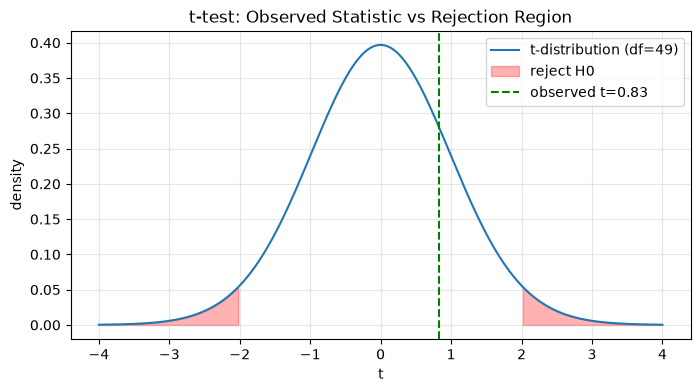

Critical value (two-tailed, alpha=0.05): +/-2.010
Observed t=0.833 is in the rejection region: False


In [2]:
# Visualize the t-distribution and p-value
df = len(sample) - 1  # degrees of freedom
x = np.linspace(-4, 4, 300)
pdf = stats.t.pdf(x, df)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, label=f"t-distribution (df={df})")
# Shade the rejection regions (two-tailed, alpha=0.05)
crit = stats.t.ppf(0.975, df)  # critical value for two-tailed 0.05
plt.fill_between(x, pdf, where=(x < -crit), color="red", alpha=0.3, label="reject H0")
plt.fill_between(x, pdf, where=(x > crit), color="red", alpha=0.3)
plt.axvline(t_stat, color="green", linestyle="--", label=f"observed t={t_stat:.2f}")
plt.xlabel("t")
plt.ylabel("density")
plt.title("t-test: Observed Statistic vs Rejection Region")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Critical value (two-tailed, alpha=0.05): +/-{crit:.3f}")
print(f"Observed t={t_stat:.3f} is in the rejection region: {abs(t_stat) > crit}")


## 9. Type I and Type II Errors

- **Type I error** (false positive): rejecting H0 when it's actually true. Probability = `alpha` (significance level).
- **Type II error** (false negative): failing to reject H0 when it's actually false. Probability = `beta`.
- **Power** = `1 - beta`: probability of correctly rejecting a false H0.

There's a tradeoff: lowering `alpha` reduces Type I errors but increases Type II errors.


In [3]:
# Type I error rate: if H0 is true, we reject it ~5% of the time (alpha=0.05)
np.random.seed(7)
n_trials = 10000
rejections = 0
for _ in range(n_trials):
    # Sample from a population with mean EXACTLY 100 (H0 true)
    sample = np.random.normal(100, 15, size=50)
    t_stat, p_value = stats.ttest_1samp(sample, 100)
    if p_value < 0.05:
        rejections += 1

print(f"When H0 is true, we rejected it {rejections}/{n_trials} times.")
print(f"Type I error rate: {rejections/n_trials:.1%} (expected ~5%)")
print("\nThis is the price of significance: 5% of the time we get a false positive.")


When H0 is true, we rejected it 483/10000 times.
Type I error rate: 4.8% (expected ~5%)

This is the price of significance: 5% of the time we get a false positive.


## 10. Two-Sample t-test

The **two-sample t-test** compares the means of two independent groups. This is used to test whether two groups differ (e.g. treatment vs control, or two model versions).


In [4]:
# Two-sample t-test: do two groups differ?
np.random.seed(11)

# Group A: mean 50; Group B: mean 53 (small real difference)
group_a = np.random.normal(50, 10, size=100)
group_b = np.random.normal(53, 10, size=100)

t_stat, p_value = stats.ttest_ind(group_a, group_b)

print(f"Group A mean: {np.mean(group_a):.2f}")
print(f"Group B mean: {np.mean(group_b):.2f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Groups differ significantly (p < 0.05): {p_value < 0.05}")

# Now test two groups with NO real difference
group_c = np.random.normal(50, 10, size=100)
group_d = np.random.normal(50, 10, size=100)
t2, p2 = stats.ttest_ind(group_c, group_d)
print(f"\nNo-difference groups: p-value = {p2:.4f}")
print(f"Correctly fail to reject H0 (p > 0.05): {p2 > 0.05}")


Group A mean: 50.12
Group B mean: 53.04
t-statistic: -2.183
p-value: 0.0302
Groups differ significantly (p < 0.05): True

No-difference groups: p-value = 0.9301
Correctly fail to reject H0 (p > 0.05): True


## 11. Effect of Sample Size

Larger samples make it easier to detect small differences (higher power). But with huge samples, even tiny, practically meaningless differences become 'statistically significant'. Always consider **practical significance** too.


In [5]:
# Sample size affects power
np.random.seed(13)

def detect_difference(n, effect=1.0):
    a = np.random.normal(50, 10, size=n)
    b = np.random.normal(50 + effect, 10, size=n)
    _, p = stats.ttest_ind(a, b)
    return p < 0.05

for n in [10, 50, 200, 1000]:
    # Power: fraction of trials where we detect the true difference
    power = np.mean([detect_difference(n) for _ in range(200)])
    print(f"n={n:5d}: power to detect effect=1.0 is {power:.0%}")

print("\nLarger samples -> higher power -> more likely to detect real effects.")


n=   10: power to detect effect=1.0 is 6%


n=   50: power to detect effect=1.0 is 4%


n=  200: power to detect effect=1.0 is 22%


n= 1000: power to detect effect=1.0 is 59%

Larger samples -> higher power -> more likely to detect real effects.


## 12. Failure Case: p-hacking

**p-hacking** is running many tests and only reporting the significant ones. If you run 20 tests at alpha=0.05, you expect ~1 false positive by chance. This is why multiple-testing corrections exist.


In [6]:
# p-hacking: many tests -> false positives
np.random.seed(17)
n_tests = 20
false_positives = 0
for _ in range(n_tests):
    # All groups have the SAME mean (H0 true for all)
    a = np.random.normal(50, 10, size=50)
    b = np.random.normal(50, 10, size=50)
    _, p = stats.ttest_ind(a, b)
    if p < 0.05:
        false_positives += 1

print(f"Ran {n_tests} tests where H0 is true for all.")
print(f"False positives (p < 0.05): {false_positives}")
print(f"Expected by chance: ~{n_tests * 0.05:.0f}")
print("\nThis is why we correct for multiple testing (e.g. Bonferroni).")


Ran 20 tests where H0 is true for all.
False positives (p < 0.05): 2
Expected by chance: ~1

This is why we correct for multiple testing (e.g. Bonferroni).


## 13. Debugging: Common Errors

- **Misinterpreting p-value**: it's not the probability H0 is true.
- **Ignoring effect size**: statistical significance != practical importance.
- **p-hacking**: running many tests without correction.
- **Wrong test**: use t-test for means, chi-square for proportions, ANOVA for 3+ groups.
- **Small samples**: t-test assumes normality; for small skewed samples use non-parametric tests.

## 14. Real-World Considerations

- **A/B testing** in product/ML uses hypothesis tests to decide if a change helps.
- **Model comparison**: use paired tests (e.g. paired t-test) when comparing models on the same data.
- **Multiple testing**: correct p-values when testing many hypotheses (e.g. many features).
- **Pre-registration**: decide hypotheses and alpha before seeing data to avoid p-hacking.

## 15. Common Mistakes

- Reporting p-value without effect size.
- Using a one-tailed test without justification.
- Treating 'not significant' as 'no effect' (could be low power).
- Comparing many groups with pairwise t-tests instead of ANOVA.

## 16. When NOT to Use

- Don't use hypothesis tests when you have the full population (no sampling uncertainty).
- Don't use t-tests for heavily skewed data or small samples - use non-parametric tests.
- Don't rely solely on p-values - report confidence intervals and effect sizes.

## 17. Challenge

Two model versions give accuracy on 30 test samples: Model A has mean accuracy 0.82, Model B has 0.85, both with std 0.05. Use a two-sample t-test to determine if Model B is significantly better (p < 0.05).


In [7]:
# Challenge: comparing two models with a t-test
np.random.seed(19)
model_a = np.random.normal(0.82, 0.05, size=30)
model_b = np.random.normal(0.85, 0.05, size=30)

t_stat, p_value = stats.ttest_ind(model_a, model_b)

print(f"Model A mean accuracy: {np.mean(model_a):.3f}")
print(f"Model B mean accuracy: {np.mean(model_b):.3f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Model B significantly better (p < 0.05): {p_value < 0.05}")


Model A mean accuracy: 0.821
Model B mean accuracy: 0.855
t-statistic: -2.975
p-value: 0.0043
Model B significantly better (p < 0.05): True


## 18. Closed-Book Recall

Without looking back:

1. What is the null hypothesis?
2. What does a p-value actually mean?
3. What is a Type I error? A Type II error?
4. When do you use a two-sample t-test?
5. What is p-hacking and why is it a problem?

## 19. Teach-Back Questions

Explain to another person:

- Why is a small p-value not '95% chance H0 is false'?
- What is the difference between statistical and practical significance?
- Why does sample size affect whether we detect a difference?

## 20. Summary

You now understand hypothesis testing: null and alternative hypotheses, p-values, significance levels, Type I/II errors, and t-tests. These tools let you make rigorous, data-driven decisions and avoid common statistical pitfalls.

## 21. Further Experiment

- Run a chi-square test for proportions.
- Apply the Bonferroni correction for multiple testing.
- Use a paired t-test to compare models on the same data.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
